# 4.0 — Análisis integral del benchmark — Food-101

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/marcoslund/ViT-for-101-food-app/blob/main/notebooks/4.0-comparativa.ipynb)

Este notebook consolida los resultados de **las ocho corridas** del benchmark (notebooks `3.1` a `3.8`) y los analiza de cara al informe. No entrena ni evalúa modelos: trabaja sobre lo que cada corrida dejó en `reports/results/<corrida>/` —métricas, predicciones por imagen, reporte por clase, confusiones e historial de entrenamiento— y sobre los artefactos del EDA en `data/processed/`.

Son cuatro arquitecturas y, para tres de ellas, más de una receta de entrenamiento:

| Arquitectura | Checkpoint | Parámetros | Rol en el benchmark | Corridas |
|---|---|---|---|---|
| **MobileViT-S** | `apple/mobilevit-small` | 5,0 M | candidato liviano | lr 5e-4 · 20 ép. (`3.1`) / lr 5e-5 · 20 ép. (`3.6`) / lr 5e-5 · 30 ép. (`3.8`) |
| **DeiT-Ti** | `facebook/deit-tiny-patch16-224` | 5,5 M | liviano, transformer puro | lr 5e-4 · 20 ép. (`3.3`) |
| **Swin-T** | `microsoft/swin-tiny-patch4-window7-224` | 27,6 M | intermedio | lr 5e-4 · 20 ép. (`3.2`) / lr 5e-4 · 30 ép. (`3.5`) |
| **ViT-B/16** | `google/vit-base-patch16-224-in21k` | 85,9 M | referencia de mayor capacidad | lr 5e-4 · 20 ép. (`3.4`) / lr 5e-5 · 20 ép. (`3.7`) |

Una receta de entrenamiento única no sirve para arquitecturas de tamaños tan distintos: lo que para una es un buen learning rate, para otra es una desventaja de varios puntos. Por eso el análisis tiene dos etapas:

1. **Elegir la receta de cada arquitectura** (secciones 1 y 2). Dentro de cada arquitectura se mide el efecto de cada cambio de receta y se elige la corrida con mejor F1 macro **de validación**. Se elige por validación y no por test para que el test siga siendo una estimación honesta.
2. **Comparar las arquitecturas** (secciones 3 a 9), cada una con su receta elegida: desempeño frente a costo, brecha según la dificultad de la clase, confusiones, ejemplos del dataset y convergencia.

**Qué produce** (lo que el informe va a citar):

- tablas en `reports/results/comparativa/*.csv` y los números clave en `reports/results/comparativa/hallazgos.json`;
- figuras en `reports/figures/comparativa-*.png` y grillas con imágenes del dataset en `reports/figures/comparativa-ejemplos-*.jpg`.

**Qué necesita:** las dependencias base del proyecto. No hace falta GPU ni el extra `deep`. Solo la sección 8 (ejemplos del dataset) necesita las imágenes de Food-101: alcanza con el `food-101.tar.gz` sin extraer, del que se sacan únicamente las ~60 imágenes que se muestran.

La lógica vive en `vit_for_101_food_app/modeling/comparison.py` y `modeling/examples.py` (con tests en `tests/`); acá solo se llaman funciones.

## 0. Entorno

Desde la raíz del repo:

```bash
uv sync
uv run jupyter lab
```

### 0.1 Parámetros

- `MOSTRAR_IMAGENES`: genera las grillas de la sección 8. Si las imágenes no están disponibles, la sección se saltea sin cortar el notebook.
- `USE_DRIVE` (solo Colab): busca el `food-101.tar.gz` en `DRIVE_DIR`, donde lo dejan los notebooks 3.x.
- `REPO_BRANCH`: rama que clona Colab.

In [1]:
MOSTRAR_IMAGENES = True

# Solo Colab
USE_DRIVE = True
DRIVE_DIR = "/content/drive/MyDrive/ceia-vpc3"
REPO_BRANCH = "main"

### 0.2 Instalación (Colab) e imports

In [2]:
import os
from pathlib import Path
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if IN_COLAB:
    REPO_URL = "https://github.com/marcoslund/ViT-for-101-food-app.git"
    REPO_DIR = "/content/ViT-for-101-food-app"
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "-q", "-b", REPO_BRANCH, REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull", "-q"], check=False)
    sys.path.insert(0, REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR], check=True)
    os.chdir(f"{REPO_DIR}/notebooks")
    if USE_DRIVE:
        from google.colab import drive

        drive.mount("/content/drive")

print(f"Colab: {IN_COLAB}")

Colab: False


In [3]:
import json

from IPython.display import Image, display
from loguru import logger
import matplotlib.pyplot as plt
import pandas as pd

# config.py loguea la ruta absoluta del proyecto al importarse: no aporta al análisis.
logger.disable("vit_for_101_food_app.config")

from vit_for_101_food_app.config import FIGURES_DIR, REPORTS_DIR
from vit_for_101_food_app.modeling import comparison as cmp
from vit_for_101_food_app.modeling import examples as ej

pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

OUT_DIR = REPORTS_DIR / "results" / "comparativa"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

REF = cmp.REFERENCE
NOMBRE = cmp.model_name

# Todas las corridas con resultados, ordenadas por arquitectura y después por receta
# (learning rate de mayor a menor, tope de épocas de menor a mayor).
todas = cmp.load_metrics(cmp.available_models())
ORDEN_ARQ = list(cmp.MODEL_COLORS)
CORRIDAS = sorted(
    todas,
    key=lambda r: (
        ORDEN_ARQ.index(todas[r]["model_key"]),
        -todas[r]["receta"]["learning_rate"],
        todas[r]["receta"]["epochs"],
    ),
)
todas = {r: todas[r] for r in CORRIDAS}
ARQUITECTURAS = [a for a in ORDEN_ARQ if any(d["model_key"] == a for d in todas.values())]


def ETIQUETA(run):
    # "ViT-B/16 · lr 5e-5 · 20 ép."
    return cmp.run_label(run, todas)


def RECETA(run):
    # "lr 5e-5 · 20 ép."
    return ETIQUETA(run).split(" · ", 1)[1]


print(f"{len(CORRIDAS)} corridas de {len(ARQUITECTURAS)} arquitecturas:")
for r in CORRIDAS:
    print(f"  {r:24s} {ETIQUETA(r)}")
print("referencia:", NOMBRE(REF))


def guardar(fig, nombre):
    ruta = FIGURES_DIR / f"comparativa-{nombre}.png"
    fig.savefig(ruta, dpi=150, bbox_inches="tight")
    print("figura:", ruta.relative_to(REPORTS_DIR.parent))


def mostrar_grilla(fig, nombre):
    # Las grillas de fotos se guardan en JPEG: en PNG pesan diez veces más.
    ruta = FIGURES_DIR / f"comparativa-{nombre}.jpg"
    fig.savefig(ruta, dpi=110, bbox_inches="tight", pil_kwargs={"quality": 85})
    plt.close(fig)
    print("figura:", ruta.relative_to(REPORTS_DIR.parent))
    display(Image(filename=ruta))


# Se va llenando a lo largo del notebook y se exporta en la sección 10.
hallazgos = {}

8 corridas de 4 arquitecturas:
  mobilevit                MobileViT-S · lr 5e-4 · 20 ép.
  mobilevit-lr5e-5         MobileViT-S · lr 5e-5 · 20 ép.
  mobilevit-lr5e-5-30ep    MobileViT-S · lr 5e-5 · 30 ép.
  vit                      ViT-B/16 · lr 5e-4 · 20 ép.
  vit-lr5e-5               ViT-B/16 · lr 5e-5 · 20 ép.
  swin                     Swin-T · lr 5e-4 · 20 ép.
  swin-30ep                Swin-T · lr 5e-4 · 30 ép.
  deit                     DeiT-Ti · lr 5e-4 · 20 ép.
referencia: ViT-B/16


## 1. Las corridas y las condiciones de la comparación

Para que una diferencia medida se pueda atribuir a la arquitectura o a la receta, todo lo demás tiene que ser igual. `check_comparable` corta si entre corridas difiere algo que no se varió a propósito: batch efectivo, semilla, weight decay, warmup, paciencia del early stopping, criterio de selección o tamaño de test. El learning rate y el tope de épocas son los **factores de diseño** de este análisis: se muestran, pero no cortan. Las épocas efectivamente entrenadas las define el early stopping.

El entorno se muestra pero no corta: importa porque las latencias de la sección 5 solo se pueden comparar si se midieron en la misma máquina.

In [4]:
condiciones = cmp.check_comparable(todas, design=("learning_rate", "epochs"))
# El learning rate se muestra en notación científica: con 4 decimales, 5e-5 se vería como 0.0001.
condiciones.loc["learning_rate"] = condiciones.loc["learning_rate"].map(cmp.fmt_lr)
cmp.present(condiciones.rename(columns=ETIQUETA))

,MobileViT-S · lr 5e-4 · 20 ép.,MobileViT-S · lr 5e-5 · 20 ép.,MobileViT-S · lr 5e-5 · 30 ép.,ViT-B/16 · lr 5e-4 · 20 ép.,ViT-B/16 · lr 5e-5 · 20 ép.,Swin-T · lr 5e-4 · 20 ép.,Swin-T · lr 5e-4 · 30 ép.,DeiT-Ti · lr 5e-4 · 20 ép.
Épocas (tope),20,20,30,20,20,20,30,20
Learning rate,5e-4,5e-5,5e-5,5e-4,5e-5,5e-4,5e-4,5e-4
Weight decay,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
Warmup,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05
Paciencia (early stopping),3,3,3,3,3,3,3,3
Métrica de selección,f1_macro,f1_macro,f1_macro,f1_macro,f1_macro,f1_macro,f1_macro,f1_macro
Semilla,42,42,42,42,42,42,42,42
Batch efectivo,32,32,32,32,32,32,32,32
Épocas entrenadas,17.0,20.0,24.0,20.0,8.0,20.0,30.0,20.0
Imágenes de test,25250,25250,25250,25250,25250,25250,25250,25250


Una fila por corrida, con su arquitectura, los dos factores de la receta, el mejor F1 macro de validación (la métrica con la que el entrenamiento eligió el checkpoint) y el resultado sobre el test completo:

In [5]:
tabla_corridas = cmp.run_table(todas)
tabla_corridas.to_csv(OUT_DIR / "corridas.csv")
cmp.present(
    tabla_corridas.drop(columns="checkpoint")
    .assign(learning_rate=tabla_corridas["learning_rate"].map(cmp.fmt_lr))
    .rename(index=ETIQUETA)
)

,Arquitectura,Learning rate,Épocas (tope),Épocas entrenadas,Mejor F1 de validación,Accuracy,F1 macro,Horas de entrenamiento
MobileViT-S · lr 5e-4 · 20 ép.,MobileViT-S,5e-4,20,17.0,0.8167,0.8605,0.8609,1.6714
MobileViT-S · lr 5e-5 · 20 ép.,MobileViT-S,5e-5,20,20.0,0.7691,0.8215,0.8207,2.0066
MobileViT-S · lr 5e-5 · 30 ép.,MobileViT-S,5e-5,30,24.0,0.7819,0.8331,0.8325,3.4646
ViT-B/16 · lr 5e-4 · 20 ép.,ViT-B/16,5e-4,20,20.0,0.7705,0.8239,0.8233,3.1189
ViT-B/16 · lr 5e-5 · 20 ép.,ViT-B/16,5e-5,20,8.0,0.8431,0.8836,0.8838,1.0893
Swin-T · lr 5e-4 · 20 ép.,Swin-T,5e-4,20,20.0,0.8149,0.8548,0.8547,1.9403
Swin-T · lr 5e-4 · 30 ép.,Swin-T,5e-4,30,30.0,0.8085,0.8552,0.8549,2.8263
DeiT-Ti · lr 5e-4 · 20 ép.,DeiT-Ti,5e-4,20,20.0,0.7204,0.7768,0.7765,1.0377


Las ocho corridas comparten todo lo que no se varió a propósito: batch efectivo de 32, semilla 42, weight decay, warmup, paciencia 3, selección por F1 macro, las mismas 25.250 imágenes de test, las mismas versiones y la misma GPU (una RTX 5060 de notebook). Difieren solo en los dos factores de diseño: el learning rate (5e-4 o 5e-5) y el tope de épocas (20 o 30).

El barrido no es simétrico, y conviene tenerlo presente al leer todo lo que sigue: ViT-B/16 y MobileViT-S se probaron con los dos learning rates; Swin-T solo cambió el tope de épocas; DeiT-Ti tiene una sola corrida. Tres corridas cortaron por early stopping antes del tope: MobileViT-S con lr 5e-4 (época 17), MobileViT-S con lr 5e-5 y 30 épocas (época 24) y ViT-B/16 con lr 5e-5 (época 8).

## 2. Efecto de la receta dentro de cada arquitectura

Antes de comparar arquitecturas hay que saber cuánto pesa la receta. Dentro de cada arquitectura, todas las corridas predijeron las mismas 25.250 imágenes de test, así que cada cambio de receta se puede medir **imagen por imagen**, con el mismo contraste pareado que se usa después entre arquitecturas:

- **Diferencia A − B**: puntos porcentuales de accuracy que la corrida A le saca a la B, con su intervalo de confianza del 95 %. Si el intervalo no incluye al cero, la diferencia no se explica por la muestra de imágenes.
- **Acierta solo A / solo B**: las imágenes discordantes, las únicas que aportan información.

Cada fila compara una corrida con la de la receta "anterior" de la misma arquitectura: el cambio de learning rate primero, y después el de tope de épocas.

In [6]:
preds_todas = cmp.load_predictions(CORRIDAS)
historias_todas = cmp.load_histories(CORRIDAS)

pares_receta = []
for arq in ARQUITECTURAS:
    corridas_arq = [r for r in CORRIDAS if todas[r]["model_key"] == arq]
    pares_receta += list(zip(corridas_arq[1:], corridas_arq[:-1]))

efecto_receta = pd.DataFrame(
    {
        f"{NOMBRE(todas[a]['model_key'])}: {RECETA(a)}  −  {RECETA(b)}": cmp.paired_difference(
            preds_todas[a], preds_todas[b]
        )
        for a, b in pares_receta
    }
).T.infer_objects()
efecto_receta.to_csv(OUT_DIR / "efecto_receta.csv")

for (a, b), fila in zip(pares_receta, efecto_receta.index):
    for k in ("diff", "ic_bajo", "ic_alto"):
        hallazgos[f"receta_{a}_vs_{b}_{k}"] = float(efecto_receta.loc[fila, k])

cmp.present_paired(efecto_receta)

,Imágenes,Accuracy de A (%),Accuracy de B (%),Diferencia A − B (puntos),"IC 95 %, desde (puntos)","IC 95 %, hasta (puntos)",Acierta solo A,Acierta solo B
MobileViT-S: lr 5e-5 · 20 ép. − lr 5e-4 · 20 ép.,25250,82.1465,86.0475,-3.9010,-4.3399,-3.4621,1125,2110
MobileViT-S: lr 5e-5 · 30 ép. − lr 5e-5 · 20 ép.,25250,83.3149,82.1465,1.1683,0.9035,1.4331,731,436
ViT-B/16: lr 5e-5 · 20 ép. − lr 5e-4 · 20 ép.,25250,88.3564,82.3881,5.9683,5.5225,6.4142,2448,941
Swin-T: lr 5e-4 · 30 ép. − lr 5e-4 · 20 ép.,25250,85.5208,85.4812,0.0396,-0.3213,0.4005,1086,1076


Las curvas de validación muestran lo mismo época por época. El punto marca la época del mejor F1 de validación, que es el checkpoint que se evaluó en test:

figura: reports/figures/comparativa-curvas-por-receta.png


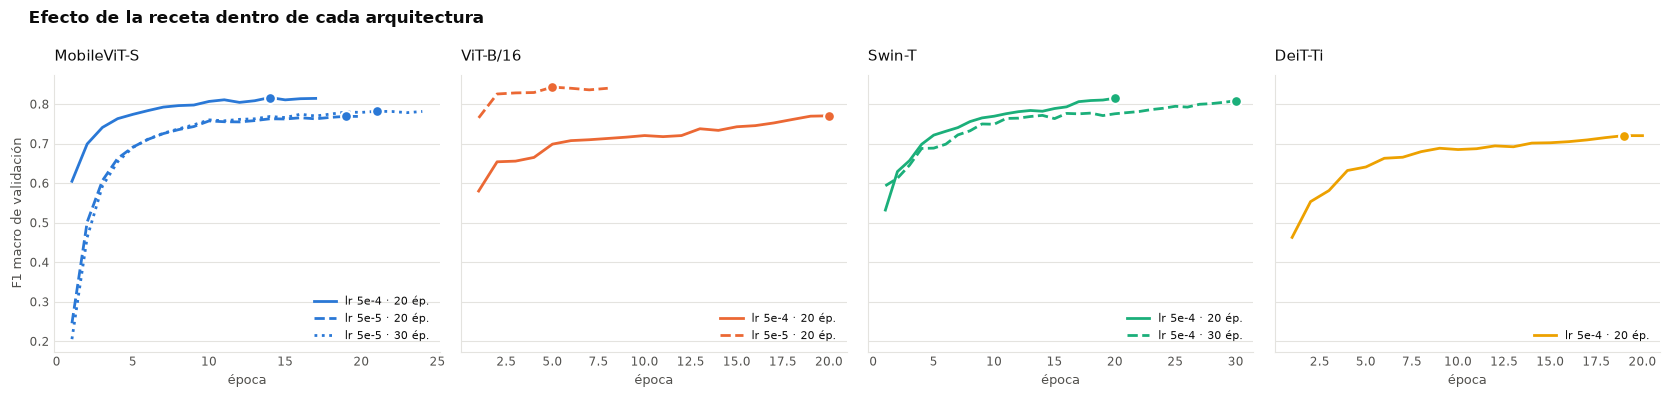

In [7]:
fig = cmp.plot_recipe_curves(historias_todas, todas)
guardar(fig, "curvas-por-receta")
plt.show()

**Lectura.** La receta pesa tanto como la arquitectura, y no pesa igual para todas:

- **ViT-B/16 necesitaba el learning rate bajo.** Bajar de 5e-4 a 5e-5 le suma unos 6,0 puntos de accuracy (IC 95 % de 5,5 a 6,4): pasa de 82,4 % a 88,4 %. La curva de validación lo muestra sin ambigüedad: con 5e-5 la primera época (0,765) ya está a la altura del mejor valor que la corrida con 5e-4 alcanzó recién en la época 20 (0,771), la segunda lo supera por 5 puntos y el mejor checkpoint llega en la época 5. Además entrenó en un tercio del tiempo (1,1 horas contra 3,1), porque el early stopping lo cortó en la época 8.
- **MobileViT-S necesitaba el learning rate alto.** El mismo cambio le resta 3,9 puntos (IC de −4,3 a −3,5): con 5e-5 arranca desde un F1 de validación de 0,25 en la primera época y 20 épocas no le alcanzan para recuperar. Darle 30 épocas recupera 1,2 puntos (IC de 0,9 a 1,4), pero sigue 2,7 puntos por debajo de la receta original. Es coherente con que MobileViT-S es un modelo chico con una cabeza de clasificación nueva: tiene más que aprender desde el checkpoint y lo aprende más rápido con pasos grandes.
- **Swin-T no gana con más épocas.** La diferencia entre 30 y 20 épocas es de 0,04 puntos y su intervalo (de −0,3 a 0,4) incluye al cero: las 1.086 imágenes que acierta solo una y las 1.076 que acierta solo la otra son ruido. En validación la corrida de 30 épocas incluso termina más abajo (0,809 contra 0,815). Como el schedule del learning rate decae linealmente hasta el tope de épocas, la corrida de 30 épocas no es "la misma con 10 épocas más": es una corrida entera con un decaimiento más lento, y Swin-T no la aprovechó.

El efecto del learning rate tiene **signo opuesto** en las dos arquitecturas donde se probó. Por eso una receta única no sirve para comparar arquitecturas de tamaños tan distintos: lo que para una es un buen valor, para la otra es una desventaja de varios puntos.

### 2.1 La corrida que representa a cada arquitectura

Se elige la de mejor F1 macro **de validación**. La tabla muestra también qué corrida habría ganado eligiendo por test: si coinciden, la elección no le debe nada al test.

In [8]:
MEJOR = cmp.best_runs(todas)  # arquitectura -> corrida, por F1 de validación
por_test = tabla_corridas.groupby("arquitectura")["f1_macro"].idxmax()

eleccion = pd.DataFrame(
    {
        "corrida": pd.Series(MEJOR),
        "mejor_val_f1": {a: todas[r]["best_val_f1_macro"] for a, r in MEJOR.items()},
        "f1_macro": {a: todas[r]["test"]["f1_macro"] for a, r in MEJOR.items()},
        "mejor_por_test": por_test,
    }
).loc[ARQUITECTURAS]
eleccion["coinciden"] = eleccion["corrida"] == eleccion["mejor_por_test"]
eleccion.to_csv(OUT_DIR / "mejor_corrida_por_arquitectura.csv")
for a, r in MEJOR.items():
    hallazgos[f"mejor_corrida_{a}"] = r

# De acá en adelante, cada arquitectura es su corrida elegida.
MODELOS = [a for a in ARQUITECTURAS if a in MEJOR]
ELEGIDAS = {a: MEJOR[a] for a in MODELOS}
metrics = cmp.load_metrics(ELEGIDAS)

vista = eleccion.copy()
vista["corrida"] = vista["corrida"].map(RECETA)
vista["mejor_por_test"] = vista["mejor_por_test"].map(RECETA)
cmp.present(
    vista.rename(
        columns={"corrida": "Receta elegida (por validación)", "mejor_por_test": "Receta que ganaría por test", "coinciden": "Coinciden"}
    )
)

,Receta elegida (por validación),Mejor F1 de validación,F1 macro,Receta que ganaría por test,Coinciden
MobileViT-S,lr 5e-4 · 20 ép.,0.8167,0.8609,lr 5e-4 · 20 ép.,True
ViT-B/16,lr 5e-5 · 20 ép.,0.8431,0.8838,lr 5e-5 · 20 ép.,True
Swin-T,lr 5e-4 · 20 ép.,0.8149,0.8547,lr 5e-4 · 30 ép.,False
DeiT-Ti,lr 5e-4 · 20 ép.,0.7204,0.7765,lr 5e-4 · 20 ép.,True


**Lectura.** La elección por validación coincide con la que habría dado el test en MobileViT-S, ViT-B/16 y DeiT-Ti. En Swin-T no coincide, pero no importa: las dos corridas dan el mismo F1 de test hasta la tercera cifra (0,8547 y 0,8549; la sección 2 ya mostró que la diferencia es ruido). Se queda la de 20 épocas, que es la que la validación prefiere y la que cuesta menos entrenar.

De acá en adelante, cada arquitectura **es** su corrida elegida: MobileViT-S, Swin-T y DeiT-Ti con lr 5e-4 y 20 épocas, ViT-B/16 con lr 5e-5 y 20 épocas. Los costos arquitectónicos no dependen de la receta.

## 3. Resultados globales

Una fila por arquitectura, con su mejor receta: desempeño sobre el **test completo** (25.250 imágenes, 250 por clase) y costo arquitectónico. El costo no depende de la receta.

Dos columnas necesitan aclaración:

- **Tamaño int8, cota teórica** es el tamaño fp32 dividido por cuatro. **Tamaño int8, medido** es el del modelo realmente cuantizado con cuantización dinámica de las capas `nn.Linear`, que es el que se midió en CPU. No coinciden cuando el modelo tiene muchas capas que no son lineales: es el caso de MobileViT-S, que combina convoluciones con bloques transformer.
- **Latencia CPU int8** es la mediana con batch 1 y un solo hilo del modelo cuantizado: es la medición más cercana a lo que pasaría en un dispositivo con recursos acotados.

In [9]:
resumen = cmp.summary_table(metrics)
resumen.to_csv(OUT_DIR / "tabla_comparativa.csv")
cmp.present(resumen.drop(columns="checkpoint"))

,Accuracy,Accuracy top-5,F1 macro,Parámetros (M),GFLOPs,Tamaño fp32 (MB),"Tamaño int8, cota teórica (MB)","Tamaño int8, medido (MB)",Latencia CPU fp32 (ms),Latencia CPU int8 (ms),Latencia GPU (ms),Épocas entrenadas,Horas de entrenamiento
MobileViT-S,0.8605,0.9688,0.8609,5.0024,4.0005,19.0825,4.7706,10.8481,105.7017,74.5258,9.7853,17.0,1.6714
ViT-B/16,0.8836,0.9754,0.8838,85.8763,35.1263,327.5922,81.8980,84.4885,566.3360,190.1634,6.7642,8.0,1.0893
Swin-T,0.8548,0.9664,0.8547,27.5970,8.9798,105.2743,26.3186,26.7229,181.9656,89.1115,29.1606,20.0,1.9403
DeiT-Ti,0.7768,0.9314,0.7765,5.5439,2.5070,21.1483,5.2871,6.0231,50.3848,19.0370,6.4546,20.0,1.0377


In [10]:
for m in MODELOS:
    hallazgos[f"{m}_accuracy"] = float(resumen.loc[m, "accuracy"])
    hallazgos[f"{m}_f1_macro"] = float(resumen.loc[m, "f1_macro"])

ranking = resumen["f1_macro"].sort_values(ascending=False)
print("Ranking por F1 macro en test:")
for i, (m, f1) in enumerate(ranking.items(), 1):
    print(f"  {i}. {NOMBRE(m):12s} {f1:.4f}   ({RECETA(MEJOR[m])})")

Ranking por F1 macro en test:
  1. ViT-B/16     0.8838   (lr 5e-5 · 20 ép.)
  2. MobileViT-S  0.8609   (lr 5e-4 · 20 ép.)
  3. Swin-T       0.8547   (lr 5e-4 · 20 ép.)
  4. DeiT-Ti      0.7765   (lr 5e-4 · 20 ép.)


**Lectura.** ViT-B/16 obtiene el mejor F1 macro del benchmark (0,884), seguido por MobileViT-S (0,861), Swin-T (0,855) y DeiT-Ti (0,777). La referencia de mayor capacidad es, efectivamente, la mejor; la pregunta del benchmark es cuánto pierde el candidato liviano y a cambio de qué. MobileViT-S conserva el 97,4 % del F1 de la referencia con 17 veces menos parámetros, 9 veces menos GFLOPs y un 39 % de su latencia en CPU int8. Las secciones que siguen miden esa pérdida imagen por imagen, por eje de costo y por clase.

## 4. Diferencias pareadas entre arquitecturas

Las cuatro arquitecturas predijeron exactamente las mismas 25.250 imágenes, así que se comparan **imagen por imagen**, igual que en la sección 2. Cada fila compara un modelo A contra un modelo B:

- **Diferencia A − B**: cuántos puntos porcentuales de accuracy le saca A a B, con su intervalo de confianza del 95 %. Si el intervalo no incluye al cero, la diferencia no se explica por la muestra de imágenes.
- **Acierta solo A / solo B**: las imágenes en que uno acierta y el otro no. Las que aciertan o fallan los dos no dicen nada sobre cuál es mejor.

Primero, cada candidato contra la referencia ViT-B/16:

In [11]:
preds = cmp.load_predictions(ELEGIDAS)
dif_ref = cmp.differences_vs(preds, MODELOS, REF)
dif_ref.to_csv(OUT_DIR / "diferencias_vs_referencia.csv")
for m in dif_ref.index:
    for k in ("diff", "ic_bajo", "ic_alto"):
        hallazgos[f"{m}_vs_{REF}_{k}"] = float(dif_ref.loc[m, k])

cmp.present_paired(dif_ref.rename(index=lambda m: f"{NOMBRE(m)} − {NOMBRE(REF)}"))

,Imágenes,Accuracy de A (%),Accuracy de B (%),Diferencia A − B (puntos),"IC 95 %, desde (puntos)","IC 95 %, hasta (puntos)",Acierta solo A,Acierta solo B
MobileViT-S − ViT-B/16,25250,86.0475,88.3564,-2.3089,-2.7470,-1.8708,1308,1891
Swin-T − ViT-B/16,25250,85.4812,88.3564,-2.8752,-3.2959,-2.4546,1116,1842
DeiT-Ti − ViT-B/16,25250,77.6752,88.3564,-10.6812,-11.1730,-10.1893,803,3500


Después, los candidatos entre sí, que es la comparación que decide qué modelo conviene para el dispositivo:

In [12]:
pares = [("mobilevit", "swin"), ("mobilevit", "deit"), ("swin", "deit")]
entre = pd.DataFrame(
    {f"{NOMBRE(a)} − {NOMBRE(b)}": cmp.paired_difference(preds[a], preds[b]) for a, b in pares}
).T.infer_objects()
entre.to_csv(OUT_DIR / "diferencias_entre_candidatos.csv")

mv_sw = cmp.paired_difference(preds["mobilevit"], preds["swin"])
hallazgos.update({f"mobilevit_vs_swin_{k}": mv_sw[k] for k in ("diff", "ic_bajo", "ic_alto")})

cmp.present_paired(entre)

,Imágenes,Accuracy de A (%),Accuracy de B (%),Diferencia A − B (puntos),"IC 95 %, desde (puntos)","IC 95 %, hasta (puntos)",Acierta solo A,Acierta solo B
MobileViT-S − Swin-T,25250,86.0475,85.4812,0.5663,0.1293,1.0034,1657,1514
MobileViT-S − DeiT-Ti,25250,86.0475,77.6752,8.3723,7.8642,8.8804,3288,1174
Swin-T − DeiT-Ti,25250,85.4812,77.6752,7.8059,7.3378,8.2741,2881,910


**Lectura.** Las tres diferencias contra la referencia son negativas y sus intervalos quedan lejos del cero: MobileViT-S queda 2,3 puntos de accuracy por debajo de ViT-B/16 (IC 95 % de −2,7 a −1,9), Swin-T 2,9 puntos (de −3,3 a −2,5) y DeiT-Ti 10,7 puntos (de −11,2 a −10,2). En términos de imágenes: de las 25.250 del test, ViT-B/16 acierta 1.891 que MobileViT-S falla, y MobileViT-S acierta 1.308 que ViT-B/16 falla. Las 22.000 restantes las aciertan o fallan los dos.

Entre candidatos, MobileViT-S supera a Swin-T por 0,6 puntos (IC de 0,1 a 1,0), una diferencia chica pero que no incluye al cero, y los dos superan a DeiT-Ti por unos 8 puntos. Que los intervalos sean tan angostos (±0,4 puntos) se debe a que las comparaciones son pareadas sobre 25.250 imágenes: las que todos aciertan o todos fallan no agregan ruido.

## 5. Desempeño frente al costo

Un panel por eje de costo, sin mezclar dos escalas en un mismo gráfico. Cada arquitectura va con su mejor receta.

Un modelo está en el **frente de Pareto** de un eje si ningún otro modelo es a la vez más barato y mejor en F1. Son las opciones que no se pueden descartar: para mejorar el F1 hay que pagar más, y para pagar menos hay que resignar F1.

figura: reports/figures/comparativa-f1-vs-costo.png


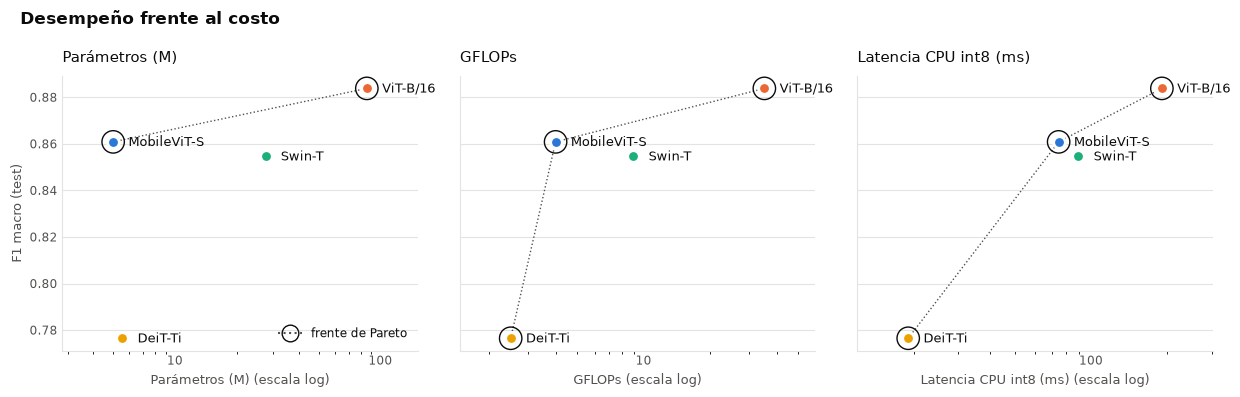

,Pareto en Parámetros (M),Pareto en GFLOPs,Pareto en Latencia CPU int8 (ms)
MobileViT-S,True,True,True
ViT-B/16,True,True,True
Swin-T,False,False,False
DeiT-Ti,False,True,True


In [13]:
EJES_COSTO = {
    "params_m": "Parámetros (M)",
    "gflops": "GFLOPs",
    "cpu_int8_ms": "Latencia CPU int8 (ms)",
}
fig = cmp.plot_tradeoff(resumen, EJES_COSTO)
guardar(fig, "f1-vs-costo")
plt.show()

pareto = pd.concat([cmp.pareto_front(resumen, col) for col in EJES_COSTO], axis=1)
pareto.columns = [f"Pareto en {etiqueta}" for etiqueta in EJES_COSTO.values()]
pareto.to_csv(OUT_DIR / "frente_de_pareto.csv")
pareto.rename(index=NOMBRE)

In [14]:
costo_rel = pd.DataFrame(
    {
        "Parámetros": resumen["params_m"] / resumen.loc["mobilevit", "params_m"],
        "GFLOPs": resumen["gflops"] / resumen.loc["mobilevit", "gflops"],
        "Latencia CPU int8": resumen["cpu_int8_ms"] / resumen.loc["mobilevit", "cpu_int8_ms"],
        "Tamaño int8 medido": resumen["size_mb_int8_medido"] / resumen.loc["mobilevit", "size_mb_int8_medido"],
    }
)
for col, clave in (("Parámetros", "params"), ("GFLOPs", "gflops"), ("Latencia CPU int8", "cpu_int8")):
    hallazgos[f"{REF}_sobre_mobilevit_{clave}"] = float(costo_rel.loc[REF, col])
    hallazgos[f"deit_sobre_mobilevit_{clave}"] = float(costo_rel.loc["deit", col])
hallazgos["mobilevit_f1_relativo_a_vit"] = float(resumen.loc["mobilevit", "f1_macro"] / resumen.loc[REF, "f1_macro"])

print("Costo de cada modelo relativo a MobileViT-S (1 = igual):")
costo_rel.rename(index=NOMBRE).round(2)

Costo de cada modelo relativo a MobileViT-S (1 = igual):


,Parámetros,GFLOPs,Latencia CPU int8,Tamaño int8 medido
MobileViT-S,1.00,1.00,1.00,1.00
ViT-B/16,17.17,8.78,2.55,7.79
Swin-T,5.52,2.24,1.20,2.46
DeiT-Ti,1.11,0.63,0.26,0.56


**Lectura.** Dos modelos están en el frente de Pareto de los tres ejes: **ViT-B/16**, porque nadie le gana en F1, y **MobileViT-S**, porque nadie que cueste menos lo iguala. Entre los dos hay 2,3 puntos de F1 de diferencia y un salto de costo de 17 veces en parámetros, 9 en GFLOPs, 8 en tamaño cuantizado y 2,5 en latencia CPU int8 (190 ms contra 75 ms). **DeiT-Ti** está en el frente de GFLOPs y de latencia porque es el más rápido de todos (19 ms en CPU int8, un cuarto de MobileViT-S), pero paga esa velocidad con 8 puntos de F1. **Swin-T** queda fuera del frente en los tres ejes: MobileViT-S lo supera en F1 siendo más chico y más rápido.

En la figura, la línea punteada que une el frente tiene una pendiente clara entre MobileViT-S y ViT-B/16: cada punto adicional de F1 cuesta, en escala logarítmica, casi un orden de magnitud más de parámetros. Para un dispositivo con recursos acotados, MobileViT-S es la opción que no se puede descartar; ViT-B/16 solo se justifica si los 2,3 puntos valen 17 veces el modelo.

## 6. Rendimiento según la dificultad de la clase

En el EDA, cada clase recibió un **margen** de dificultad (cuánto se parece a su vecina más cercana en el espacio de embeddings de CLIP) y, a partir de él, un tercil: fácil, medio o difícil. Ese ranking se fijó **antes** de entrenar, así que sirve para preguntar dónde marca diferencia la capacidad del modelo sin mirar los resultados para decidirlo.

### 6.1 Subset del benchmark

Cada notebook 3.x evaluó su modelo sobre el subset estratificado del EDA (2.525 imágenes, 25 por clase). Es la medición que ya está en cada `metrics.json`:

In [15]:
subset = cmp.load_benchmark_subset()
dificultad = cmp.load_class_difficulty()
etiqueta = dificultad["label"].to_dict()

por_tercil = pd.DataFrame(
    {m: {g: v["accuracy"] for g, v in metrics[m]["benchmark_por_tercil"].items()} for m in MODELOS}
).loc[["facil", "medio", "dificil", "subset"]]
por_tercil.to_csv(OUT_DIR / "accuracy_por_tercil_subset.csv")
cmp.present(por_tercil)

,MobileViT-S,ViT-B/16,Swin-T,DeiT-Ti
Fácil,0.9282,0.9447,0.9247,0.8776
Medio,0.8752,0.9018,0.8618,0.7818
Difícil,0.7824,0.8224,0.7882,0.7047
Subset,0.8618,0.8895,0.8582,0.7881


In [16]:
preds_t = cmp.with_tercil(preds, dificultad)

# El tercil del subset y el de class_difficulty.csv tienen que ser el mismo ranking.
control = subset[["rel", "tercil"]].merge(preds_t[["rel", "tercil"]], on="rel", suffixes=("_subset", ""))
assert (control["tercil_subset"] == control["tercil"]).all()

brecha_subset = cmp.gap_by_tercil(preds_t[preds_t["rel"].isin(subset["rel"])], MODELOS, REF)
brecha_subset.to_csv(OUT_DIR / "brecha_por_tercil_subset.csv", index=False)
# A = el modelo de la fila, B = la referencia
cmp.present_paired(brecha_subset[["tercil", "modelo", "n", "diff", "ic_bajo", "ic_alto"]])

,Tercil,Modelo,Imágenes,Diferencia A − B (puntos),"IC 95 %, desde (puntos)","IC 95 %, hasta (puntos)"
0,Fácil,MobileViT-S,850,-1.6471,-3.5731,0.2790
1,Fácil,Swin-T,850,-2.0000,-3.7357,-0.2643
2,Fácil,DeiT-Ti,850,-6.7059,-8.8340,-4.5778
3,Medio,MobileViT-S,825,-2.6667,-4.9131,-0.4202
4,Medio,Swin-T,825,-4.0000,-6.1732,-1.8268
5,Medio,DeiT-Ti,825,-12.0000,-14.6146,-9.3854
6,Difícil,MobileViT-S,850,-4.0000,-6.7150,-1.2850
7,Difícil,Swin-T,850,-3.4118,-6.1402,-0.6834
8,Difícil,DeiT-Ti,850,-11.7647,-14.6469,-8.8825


Con unas 850 imágenes por tercil, los intervalos son anchos (del orden de ±3 puntos): alcanzan para ver el signo de cada diferencia, pero no para comparar su tamaño entre terciles.

### 6.2 Test completo por tercil

El mismo ranking aplicado a las 25.250 imágenes de test (unas 8.500 por tercil). Con diez veces más imágenes, los intervalos se achican lo suficiente para comparar terciles entre sí.

figura: reports/figures/comparativa-brecha-por-tercil.png


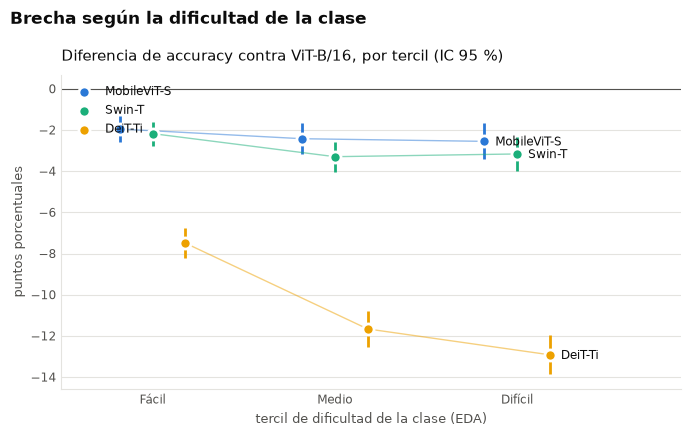

Diferencia de accuracy contra ViT-B/16, en puntos porcentuales:


tercil,Fácil,Medio,Difícil
modelo,,,
MobileViT-S,-1.95,-2.42,-2.55
Swin-T,-2.18,-3.30,-3.16
DeiT-Ti,-7.49,-11.66,-12.92


In [17]:
brecha_test = cmp.gap_by_tercil(preds_t, MODELOS, REF)
brecha_test.to_csv(OUT_DIR / "brecha_por_tercil_test.csv", index=False)

fig = cmp.plot_gap_by_tercil(brecha_test, REF)
guardar(fig, "brecha-por-tercil")
plt.show()

tabla_brecha = brecha_test.pivot(index="modelo", columns="tercil", values="diff")[list(cmp.TERCILES)] * 100
for m in tabla_brecha.index:
    for t in cmp.TERCILES:
        hallazgos[f"{m}_vs_{REF}_{t}_pp"] = float(tabla_brecha.loc[m, t])

print(f"Diferencia de accuracy contra {NOMBRE(REF)}, en puntos porcentuales:")
cmp.present(tabla_brecha.loc[[m for m in MODELOS if m != REF]]).round(2)

**Lectura.** La brecha es **pareja entre terciles** para los dos candidatos fuertes. MobileViT-S queda 1,9 puntos por debajo en las clases fáciles, 2,4 en las medias y 2,6 en las difíciles; Swin-T, 2,2, 3,3 y 3,2. Los intervalos de los tres terciles se superponen: la ventaja de la referencia no se concentra en las clases difíciles, es un desplazamiento uniforme. La hipótesis de que la capacidad extra de ViT-B/16 marcaría diferencia sobre todo en las clases que el EDA señaló como confundibles no se confirma para MobileViT-S ni para Swin-T. Para DeiT-Ti sí hay una dependencia clara: pierde 7,5 puntos en las fáciles y casi 13 en las difíciles.

El subset del benchmark (6.1) apunta en la misma dirección pero con intervalos de ±2 a ±3 puntos: con 850 imágenes por tercil, el intervalo de MobileViT-S en el tercil fácil incluye al cero. El test completo (6.2) es el que permite afirmar algo.

### 6.3 Clase por clase

La brecha de F1 contra la referencia, clase por clase, contra el margen de dificultad del EDA. `Spearman ρ` mide si la brecha depende de la dificultad: cerca de 0, la brecha es pareja; negativo, el candidato gana más (o pierde menos) en las clases difíciles; positivo, lo contrario.

In [18]:
por_clase = cmp.per_class_gap(ELEGIDAS, dificultad, REF)
por_clase.to_csv(OUT_DIR / "brecha_por_clase.csv")

planitud = pd.DataFrame([cmp.flatness(por_clase, m) for m in MODELOS if m != REF]).set_index("modelo")
planitud.to_csv(OUT_DIR / "brecha_vs_dificultad.csv")
for m in planitud.index:
    hallazgos[f"{m}_spearman_rho"] = float(planitud.loc[m, "spearman_rho"])
    hallazgos[f"{m}_clases_gana_vs_{REF}"] = int(planitud.loc[m, "clases_gana"])
    hallazgos[f"{m}_clases_pierde_vs_{REF}"] = int(planitud.loc[m, "clases_pierde"])
cmp.present(planitud)

,Brecha media,Desvío de la brecha,Clases en que gana,Clases en que pierde,Spearman ρ,p (Spearman),Pendiente
modelo,,,,,,,
MobileViT-S,-0.0230,0.0266,19,82,0.1584,1.1359e-01,0.1182
Swin-T,-0.0292,0.0242,11,90,0.1657,9.7753e-02,0.1355
DeiT-Ti,-0.1073,0.0460,0,101,0.4919,1.7514e-07,0.7580


figura: reports/figures/comparativa-brecha-por-clase-mobilevit.png


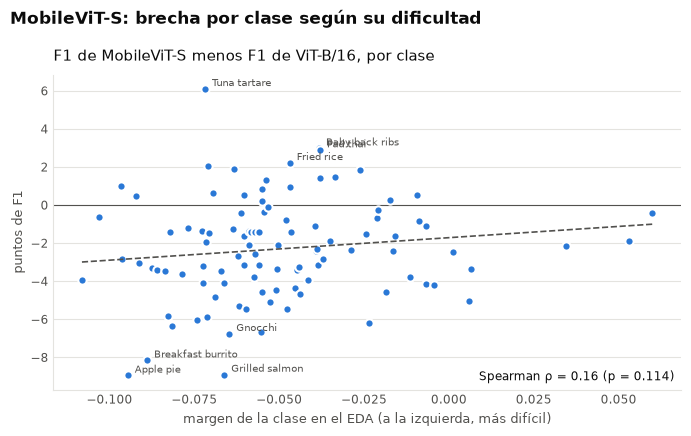

figura: reports/figures/comparativa-brecha-por-clase-swin.png


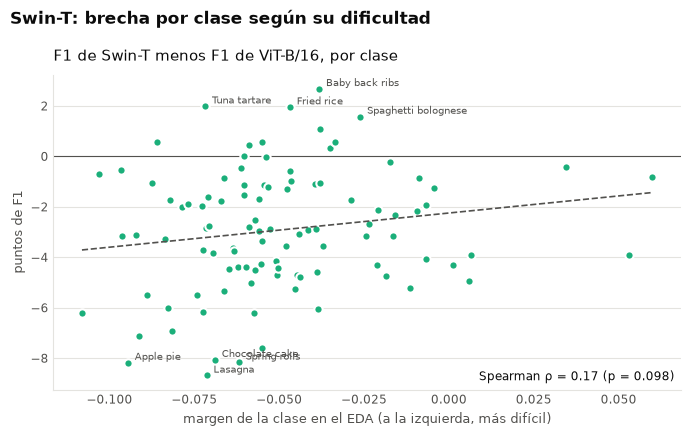

In [19]:
for m in ("mobilevit", "swin"):
    fig = cmp.plot_class_gap(por_clase, m, REF)
    guardar(fig, f"brecha-por-clase-{m}")
    plt.show()

Las clases donde MobileViT-S más supera a la referencia y aquellas en que más queda por debajo, con su vecina más confundible según el EDA. La diferencia de F1 va en puntos:

In [20]:
cols = ["label", "tercil", "vecino_mas_cercano", "f1_mobilevit", f"f1_{REF}", "gap_mobilevit"]
ordenadas = por_clase.sort_values("gap_mobilevit", ascending=False)
gana_clases = ordenadas[ordenadas["gap_mobilevit"] > 0]
pierde_clases = ordenadas[ordenadas["gap_mobilevit"] < 0].iloc[::-1]
MEJORES = gana_clases.index[:4].tolist()
PEORES = pierde_clases.index[:4].tolist()


def vista_clases(tabla):
    vista = tabla[cols].assign(gap_mobilevit=tabla["gap_mobilevit"] * 100)
    return cmp.present(vista.rename(columns={"gap_mobilevit": "Diferencia de F1 (puntos)"}))


print(f"Las {min(8, len(gana_clases))} clases (de {len(gana_clases)}) donde MobileViT-S más supera a {NOMBRE(REF)}:")
display(vista_clases(gana_clases.head(8)))
print(f"Las {min(8, len(pierde_clases))} clases (de {len(pierde_clases)}) donde MobileViT-S más queda por debajo de {NOMBRE(REF)}:")
display(vista_clases(pierde_clases.head(8)))

Las 8 clases (de 19) donde MobileViT-S más supera a ViT-B/16:


,Clase,Tercil,Vecina más confundible,F1 MobileViT-S,F1 ViT-B/16,Diferencia de F1 (puntos)
tuna_tartare,Tuna tartare,Difícil,Beef tartare,0.8176,0.7565,6.1071
baby_back_ribs,Baby back ribs,Fácil,Steak,0.8530,0.8231,2.9885
pad_thai,Pad thai,Fácil,Fried rice,0.9341,0.9053,2.8869
fried_rice,Fried rice,Medio,Pad thai,0.8814,0.8592,2.2217
risotto,Risotto,Difícil,Gnocchi,0.8178,0.7974,2.0372
cannoli,Cannoli,Difícil,Beignets,0.9357,0.9170,1.8731
spaghetti_bolognese,Spaghetti bolognese,Fácil,Spaghetti carbonara,0.9449,0.9266,1.8328
spaghetti_carbonara,Spaghetti carbonara,Fácil,Spaghetti bolognese,0.9492,0.9347,1.4525


Las 8 clases (de 82) donde MobileViT-S más queda por debajo de ViT-B/16:


,Clase,Tercil,Vecina más confundible,F1 MobileViT-S,F1 ViT-B/16,Diferencia de F1 (puntos)
apple_pie,Apple pie,Difícil,Baklava,0.6725,0.7619,-8.9454
grilled_salmon,Grilled salmon,Difícil,Pork chop,0.7786,0.8676,-8.8991
breakfast_burrito,Breakfast burrito,Difícil,Chicken quesadilla,0.7597,0.8412,-8.1512
gnocchi,Gnocchi,Difícil,Ravioli,0.7925,0.8600,-6.7588
omelette,Omelette,Medio,Eggs benedict,0.7726,0.8393,-6.6756
samosa,Samosa,Difícil,Spring rolls,0.8537,0.9172,-6.3513
ramen,Ramen,Fácil,Pho,0.8834,0.9451,-6.1662
ravioli,Ravioli,Difícil,Gnocchi,0.7220,0.7821,-6.0128


**Lectura.** MobileViT-S queda por debajo de la referencia en 82 de las 101 clases y la supera en 19, con una brecha media de −2,3 puntos de F1 y un desvío de 2,7: la mayoría de las clases están a menos de 5 puntos. La correlación con el margen es positiva pero débil (ρ ≈ 0,16): si algo, MobileViT-S pierde un poco más en las clases difíciles, pero la brecha es esencialmente plana. Swin-T se comporta igual (ρ ≈ 0,17, pierde en 90 clases). DeiT-Ti pierde en las 101 y su brecha sí crece con la dificultad (ρ ≈ 0,49).

Las clases donde MobileViT-S gana son pocas y las ventajas chicas: la mayor es tuna tartare (6 puntos de F1), seguida de baby back ribs, pad thai y fried rice con 2 a 3 puntos. Donde más pierde, la diferencia es de 6 a 9 puntos: apple pie, grilled salmon, breakfast burrito, gnocchi, omelette, samosa, ramen y ravioli. Seis de esas ocho son del tercil difícil, y en varias la vecina más confundible del EDA es justamente la clase hacia la que MobileViT-S se equivoca (gnocchi ↔ ravioli, ramen → pho, samosa → spring rolls). La sección 8 muestra las imágenes.

## 7. Confusiones entre clases

Los pares (clase real → clase predicha) más frecuentes, con cuántas veces los cometió cada modelo. Están ordenados por el total: arriba quedan las confusiones que comparten todas las arquitecturas, que hablan más del dataset que de un modelo en particular.

In [21]:
confusiones = cmp.confusion_pairs(ELEGIDAS, top=200)
confusiones.to_csv(OUT_DIR / "confusiones_compartidas.csv", index=False)

vista = confusiones.head(12).copy()
vista["clase_real"] = vista["clase_real"].map(etiqueta)
vista["clase_predicha"] = vista["clase_predicha"].map(etiqueta)
cmp.present(vista)

,Clase real,Clase predicha,MobileViT-S,ViT-B/16,Swin-T,DeiT-Ti,Total
0,Filet mignon,Steak,50,55,33,46,184
1,Steak,Filet mignon,35,25,40,46,146
2,Chocolate cake,Chocolate mousse,32,19,35,33,119
3,Pork chop,Steak,31,20,25,26,102
4,Chocolate mousse,Chocolate cake,19,26,29,25,99
5,Prime rib,Steak,30,18,24,22,94
6,Tuna tartare,Beef tartare,26,23,17,28,94
7,Apple pie,Bread pudding,19,17,19,15,70
8,Ravioli,Gnocchi,25,8,12,22,67
9,Beef tartare,Tuna tartare,12,15,15,21,63


In [22]:
todos_fallan = ~preds[MODELOS].any(axis=1)
todos_aciertan = preds[MODELOS].all(axis=1)
predicciones = preds[[f"pred_{m}" for m in MODELOS]]
misma_clase = todos_fallan & predicciones.nunique(axis=1).eq(1)

hallazgos["pct_aciertan_los_cuatro"] = float(todos_aciertan.mean() * 100)
hallazgos["pct_fallan_los_cuatro"] = float(todos_fallan.mean() * 100)
hallazgos["n_fallan_los_cuatro_misma_clase"] = int(misma_clase.sum())
por_tercil_fallan = preds_t.assign(f=todos_fallan).groupby("tercil")["f"].mean()[list(cmp.TERCILES)] * 100
for t in cmp.TERCILES:
    hallazgos[f"pct_fallan_los_cuatro_{t}"] = float(por_tercil_fallan[t])

print(f"aciertan los cuatro modelos: {todos_aciertan.mean():.1%}")
print(f"fallan los cuatro modelos:   {todos_fallan.mean():.1%} ({todos_fallan.sum()} imágenes)")
print(f"  ...y coinciden en la misma clase equivocada: {misma_clase.sum()} imágenes")
print("fallan los cuatro, por tercil (%):")
cmp.present(por_tercil_fallan.rename("fallan los cuatro (%)").to_frame()).round(2)

aciertan los cuatro modelos: 69.0%
fallan los cuatro modelos:   4.5% (1133 imágenes)
  ...y coinciden en la misma clase equivocada: 280 imágenes
fallan los cuatro, por tercil (%):


,fallan los cuatro (%)
tercil,
Fácil,2.45
Medio,3.76
Difícil,7.24


**Lectura.** Las confusiones dominantes son las mismas para los cuatro modelos: steak ↔ filet mignon (330 confusiones sumando los dos sentidos), chocolate cake ↔ chocolate mousse (218), tuna tartare ↔ beef tartare (157) y los cortes de carne (pork chop, prime rib) predichos como steak. Todas las clases involucradas pertenecen al tercil difícil del EDA, y la capacidad extra de la referencia no las elimina: ViT-B/16 confunde filet mignon con steak 55 veces, más que cualquier otro modelo.

El 69 % del test lo aciertan los cuatro modelos y el 4,5 % (1.133 imágenes) lo fallan los cuatro; en 280 de esas imágenes los cuatro predicen **la misma** clase equivocada. La proporción de fallas compartidas se triplica entre el tercil fácil (2,5 %) y el difícil (7,2 %). Ese núcleo de errores comunes es el techo del dataset, no de los modelos: la sección 8.4 muestra que en buena parte de esos casos la predicción común es razonable.

## 8. Ejemplos del dataset

Las métricas dicen cuánto acierta cada modelo; las imágenes muestran en qué. Las grillas se arman a partir de las predicciones por imagen, con semilla fija, así que la selección es reproducible. Cada imagen se muestra recortada al cuadrado central, como la ve el modelo. Las figuras se guardan en `reports/figures/comparativa-ejemplos-*.jpg`.

Las imágenes se buscan en el cache de preprocesamiento, en el dataset extraído o, si no están, se sacan directamente del `food-101.tar.gz` sin descomprimirlo. Si no hay ninguna fuente disponible, esta sección se saltea.

In [23]:
TAR = ej.TAR_PATH
if IN_COLAB and USE_DRIVE and Path(DRIVE_DIR, "food-101.tar.gz").is_file():
    TAR = Path(DRIVE_DIR, "food-101.tar.gz")

hay_imagenes = MOSTRAR_IMAGENES and (TAR.is_file() or any(ej.locate(preds["rel"].head(50)).values()))
print("fuente de imágenes:", TAR.name if TAR.is_file() else "cache / dataset extraído")
print("se muestran ejemplos:", hay_imagenes)
if MOSTRAR_IMAGENES and not hay_imagenes:
    print("No se encontraron las imágenes: correr `make data` o dejar food-101.tar.gz en data/raw/.")

fuente de imágenes: food-101.tar.gz
se muestran ejemplos: True


In [24]:
# Selección de todas las imágenes de la sección, para extraerlas del tar en una sola pasada.
aciertos = preds[MODELOS].sum(axis=1)


def cuantos_predicen(clase):
    return (predicciones == clase).sum(axis=1)


# 8.1: los pares más confundidos. Por clase, dos aciertos de los cuatro modelos y una
# imagen que al menos tres modelos ven como la otra clase del par.
PARES = cmp.unordered_pairs(confusiones, top=4)
filas_pares, sel_pares = [], []
for par in PARES.itertuples():
    imagenes = []
    for real, otra in ((par.clase_a, par.clase_b), (par.clase_b, par.clase_a)):
        # Una clase puede aparecer en más de un par (steak): no repetir imágenes.
        de_la_clase = (preds["class_dir"] == real) & ~preds["rel"].isin(sel_pares)
        tipicas = ej.pick(preds, de_la_clase & todos_aciertan, [real], per_class=2)
        k = cuantos_predicen(otra)
        confundida = ej.pick(preds, de_la_clase & (k >= 3), [real], per_class=1)
        imagenes += [(r, f"{etiqueta[real]}\nla aciertan los 4") for r in tipicas["rel"]]
        imagenes += [
            (r, f"{etiqueta[real]}\n{k[i]}/4 la ven como\n{etiqueta[otra]}")
            for i, r in zip(confundida.index, confundida["rel"])
        ]
        sel_pares += list(tipicas["rel"]) + list(confundida["rel"])
    filas_pares.append(
        (f"{etiqueta[par.clase_a]} ↔ {etiqueta[par.clase_b]} · {par.total} confusiones entre los cuatro modelos", imagenes)
    )

# 8.2 y 8.3: clases donde MobileViT-S más gana y más pierde contra la referencia.
gana = ej.pick(preds, preds["mobilevit"] & ~preds[REF], MEJORES, per_class=4)
pierde = ej.pick(preds, ~preds["mobilevit"] & preds[REF], PEORES, per_class=4)

# 8.4: imágenes que los cuatro modelos fallan prediciendo la misma clase.
comunes = ej.pick(preds, misma_clase, n=8)

rutas = {}
if hay_imagenes:
    todas_las_imagenes = sel_pares + list(gana["rel"]) + list(pierde["rel"]) + list(comunes["rel"])
    rutas = ej.ensure_images(todas_las_imagenes, TAR)
    print(f"{len(rutas)} de {len(set(todas_las_imagenes))} imágenes disponibles")

62 de 62 imágenes disponibles


### 8.1 Los pares que más se confunden

Para cada uno de los cuatro pares con más confusiones (sumando los dos sentidos y los cuatro modelos): dos imágenes típicas de cada clase, que los cuatro modelos aciertan, y una imagen que al menos tres modelos asignan a la otra clase del par.

figura: reports/figures/comparativa-ejemplos-pares-confundidos.jpg


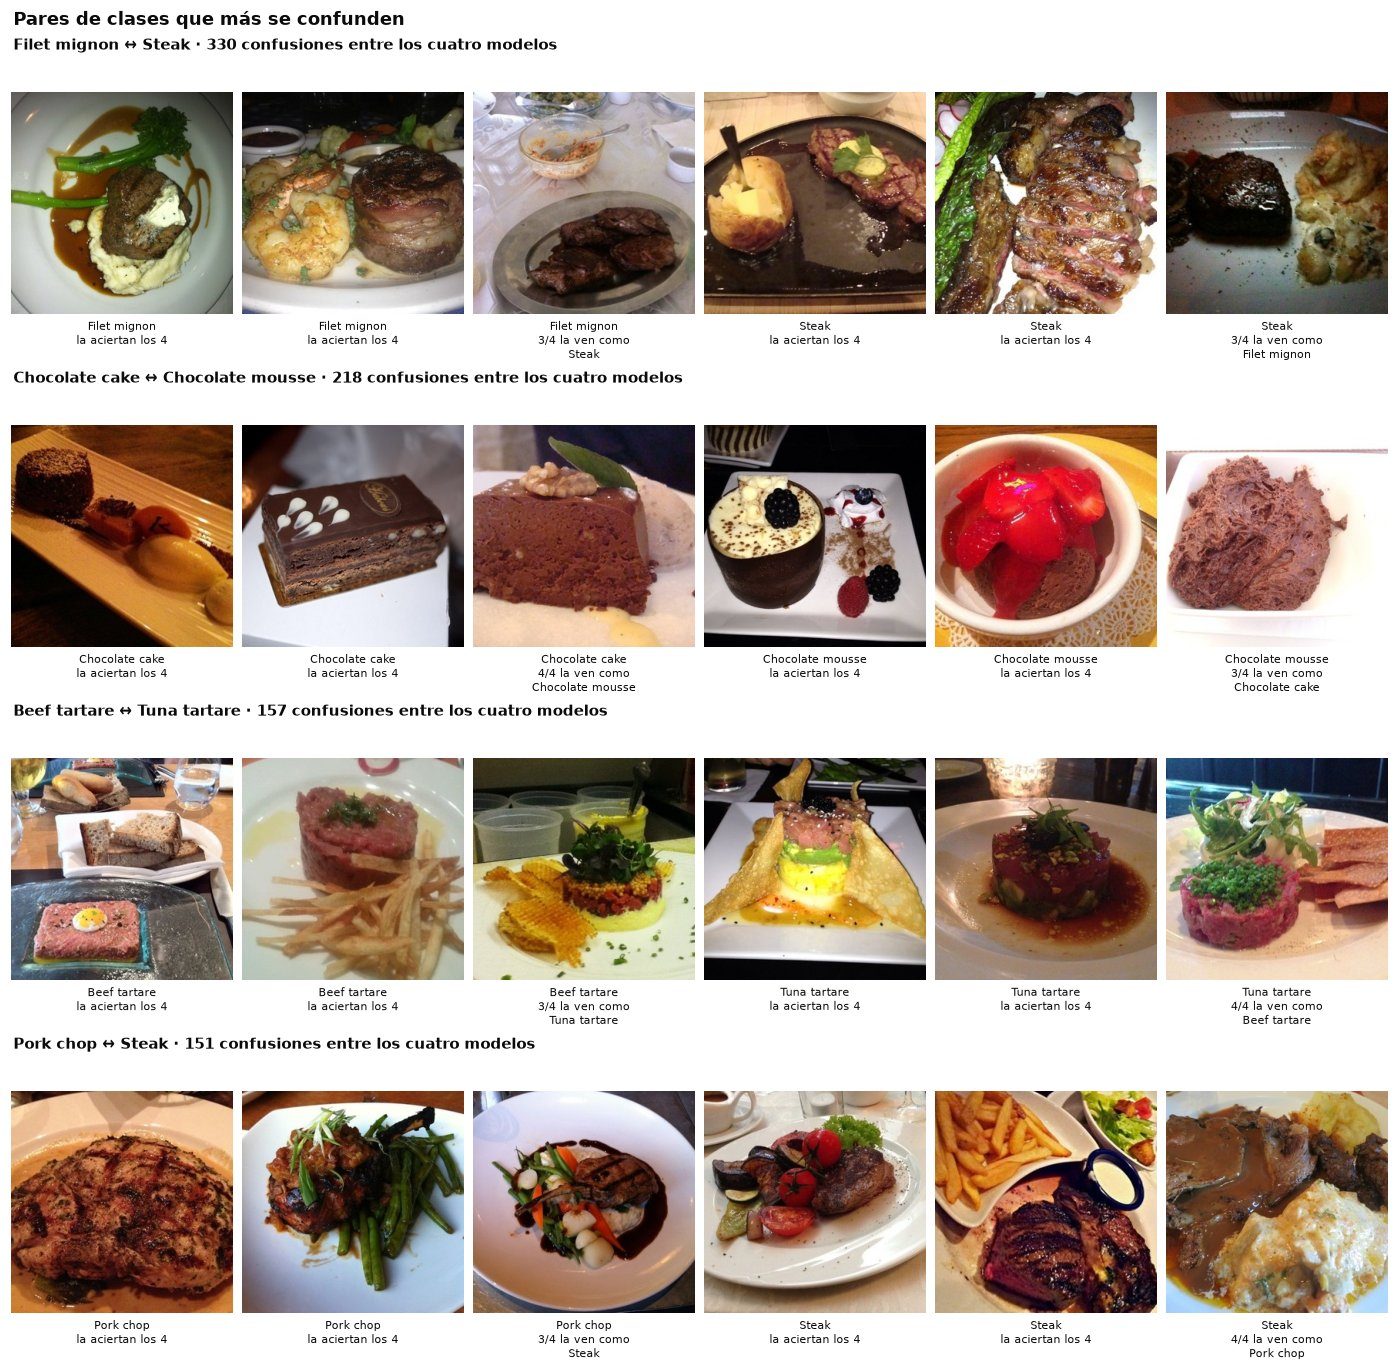

In [25]:
if hay_imagenes:
    fig = ej.plot_rows(filas_pares, rutas, "Pares de clases que más se confunden")
    mostrar_grilla(fig, "ejemplos-pares-confundidos")

Las imágenes explican las confusiones mejor que la tabla. Steak, filet mignon y pork chop son, en la foto, el mismo objeto: carne cocida en un plato, con guarnición y salsa; lo que las distingue es el corte y el grosor, que desde el ángulo de la foto muchas veces no se ve (la pieza redonda sobre puré que tres modelos ven como filet mignon es, por etiqueta, un steak; la carne fileteada con salsa que los cuatro ven como pork chop también). Entre chocolate cake y chocolate mousse, la frontera es la textura: una porción de torta de textura aireada se va a mousse en los cuatro modelos. Los dos tartares se sirven igual, en torre con hojas verdes encima, y el color del pescado crudo y el de la carne cruda se parecen bajo luz de restaurante.

### 8.2 Donde MobileViT-S supera a la referencia

Las clases con mayor ventaja de MobileViT-S sobre ViT-B/16. Cada imagen la acierta MobileViT-S y la falla ViT-B/16; el epígrafe dice qué predijo la referencia.

figura: reports/figures/comparativa-ejemplos-mobilevit-supera-vit.jpg


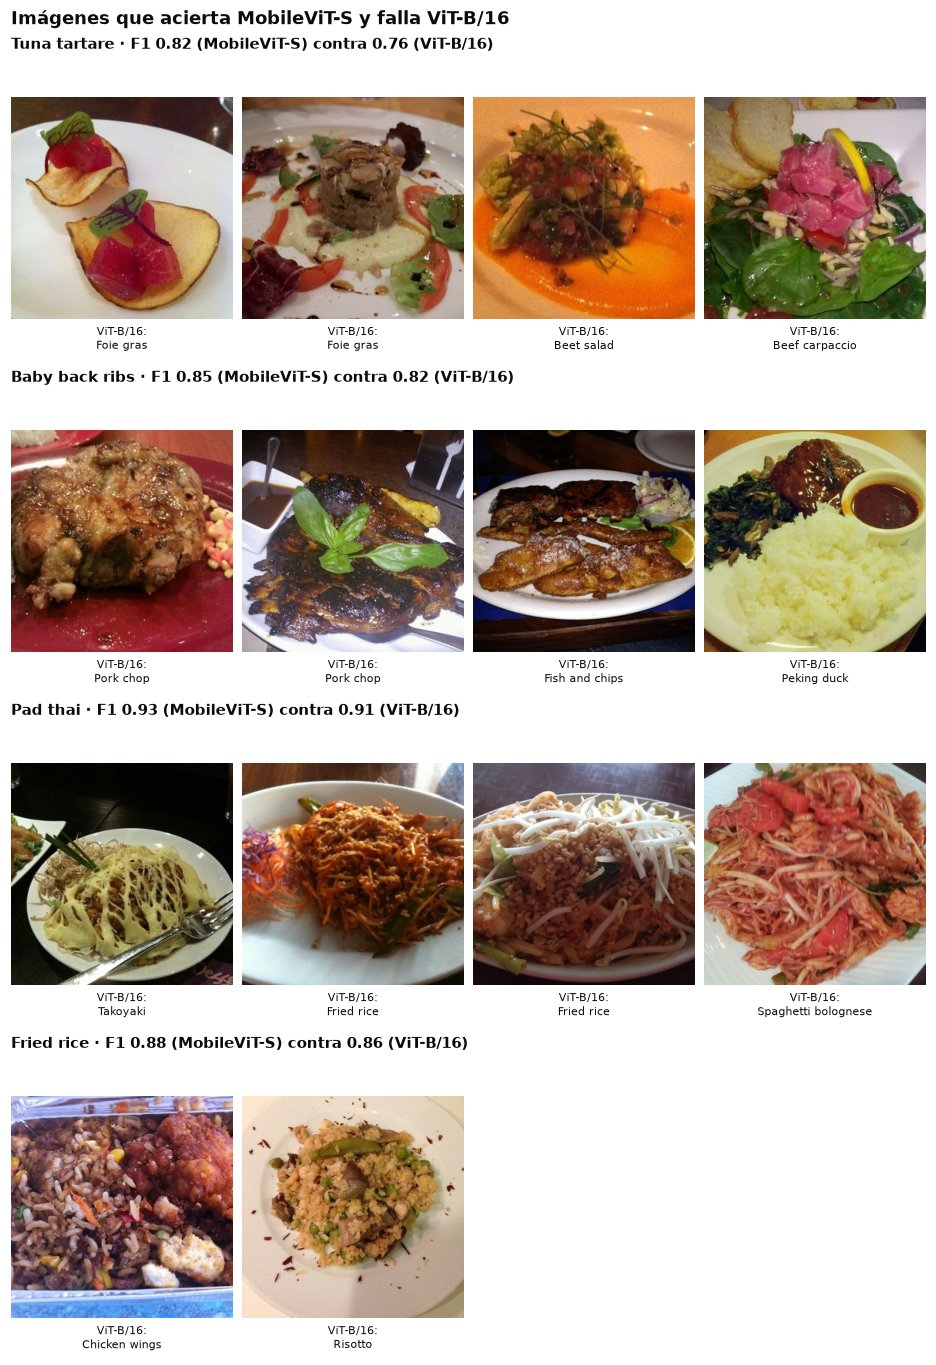

In [26]:
if hay_imagenes:
    filas = ej.rows_by_class(
        gana,
        caption=lambda r: f"{NOMBRE(REF)}:\n{etiqueta[getattr(r, 'pred_' + REF)]}",
        row_title=lambda c: (
            f"{etiqueta[c]} · F1 {por_clase.loc[c, 'f1_mobilevit']:.2f} (MobileViT-S) "
            f"contra {por_clase.loc[c, 'f1_' + REF]:.2f} ({NOMBRE(REF)})"
        ),
    )
    fig = ej.plot_rows(filas, rutas, f"Imágenes que acierta MobileViT-S y falla {NOMBRE(REF)}")
    mostrar_grilla(fig, "ejemplos-mobilevit-supera-vit")

Son las clases donde MobileViT-S saca una ventaja, chica, sobre la referencia. En tuna tartare, la mayor (6 puntos), los errores de ViT-B/16 van hacia platos con la misma presentación general: foie gras (una pieza sobre tostada), beet salad y beef carpaccio (rojo crudo sobre verde). En baby back ribs la referencia ve pork chop, fish and chips o peking duck; en pad thai, fried rice o spaghetti bolognese; en fried rice, chicken wings o risotto. Son confusiones entre platos de la misma familia visual, no errores groseros, y el número de imágenes por clase es bajo: la ventaja de MobileViT-S acá es real pero marginal.

### 8.3 Donde la referencia supera a MobileViT-S

Las clases donde MobileViT-S queda más por debajo de ViT-B/16. Cada imagen la acierta la referencia y la falla MobileViT-S; el epígrafe dice qué predijo MobileViT-S.

figura: reports/figures/comparativa-ejemplos-vit-supera-mobilevit.jpg


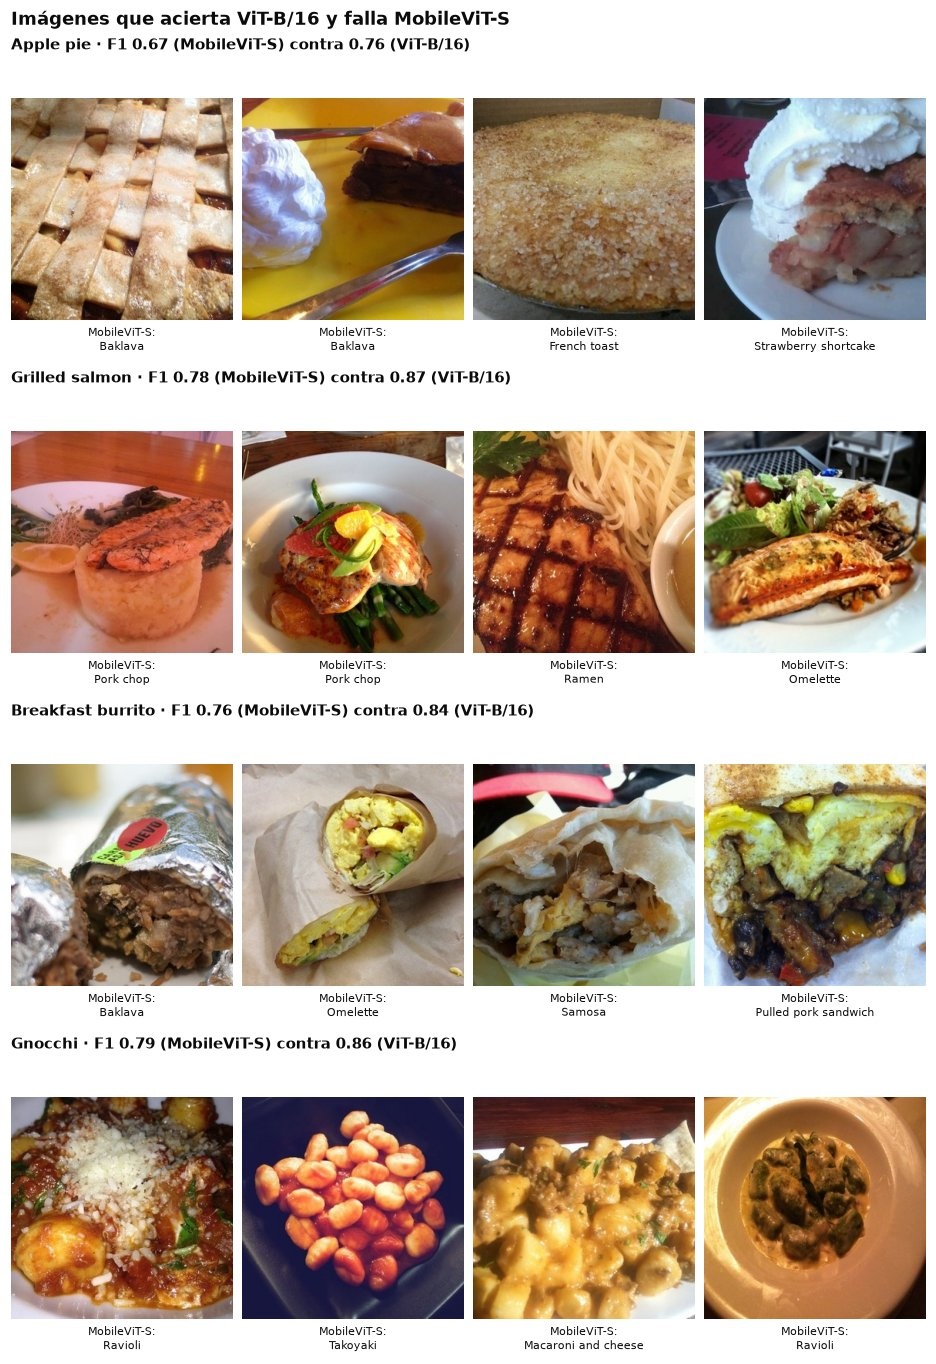

In [27]:
if hay_imagenes:
    filas = ej.rows_by_class(
        pierde,
        caption=lambda r: f"MobileViT-S:\n{etiqueta[r.pred_mobilevit]}",
        row_title=lambda c: (
            f"{etiqueta[c]} · F1 {por_clase.loc[c, 'f1_mobilevit']:.2f} (MobileViT-S) "
            f"contra {por_clase.loc[c, 'f1_' + REF]:.2f} ({NOMBRE(REF)})"
        ),
    )
    fig = ej.plot_rows(filas, rutas, f"Imágenes que acierta {NOMBRE(REF)} y falla MobileViT-S")
    mostrar_grilla(fig, "ejemplos-vit-supera-mobilevit")

Las clases donde la referencia más le gana a MobileViT-S son también de frontera difusa, pero la brecha es mayor (6 a 9 puntos). En apple pie, MobileViT-S ve baklava, french toast o strawberry shortcake cuando la foto muestra solo la cobertura (enrejado dorado, crema batida); en grilled salmon ve pork chop, ramen u omelette según la guarnición domine la foto; en breakfast burrito el envoltorio cortado se va a samosa o pulled pork sandwich; en gnocchi, hacia ravioli y macaroni and cheese. En todos los casos el plato etiquetado está presente pero comparte color y textura con la predicción, y ViT-B/16 lo resuelve. Es el patrón que se esperaba de un modelo con 17 veces más parámetros: distingue mejor cuando el indicio es sutil.

### 8.4 Errores que comparten los cuatro modelos

Imágenes que los cuatro modelos fallan **y** asignan a la misma clase equivocada. Cuando cuatro arquitecturas distintas coinciden en el error, la causa más probable está en la imagen: un plato que visualmente pertenece a otra clase, una foto donde el plato etiquetado no es el protagonista, o una etiqueta discutible.

figura: reports/figures/comparativa-ejemplos-errores-compartidos.jpg


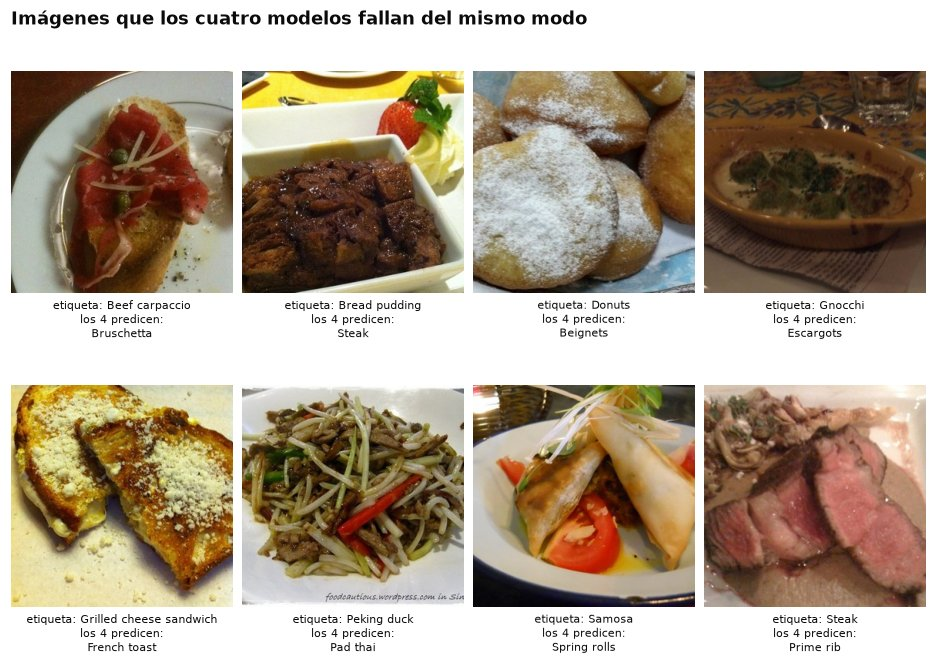

In [28]:
if hay_imagenes:
    imagenes = [
        (r.rel, f"etiqueta: {etiqueta[r.class_dir]}\nlos 4 predicen:\n{etiqueta[r.pred_mobilevit]}")
        for r in comunes.itertuples()
    ]
    filas = [("", imagenes[i : i + 4]) for i in range(0, len(imagenes), 4)]
    fig = ej.plot_rows(filas, rutas, "Imágenes que los cuatro modelos fallan del mismo modo")
    mostrar_grilla(fig, "ejemplos-errores-compartidos")

En varios de estos casos la predicción común es defendible: un beef carpaccio servido sobre pan es visualmente una bruschetta, un bread pudding en cubos oscuros con salsa parece carne, los donuts con azúcar impalpable son beignets, los gnocchi gratinados en cazuela parecen escargots, un grilled cheese espolvoreado parece french toast, un salteado de pato con brotes es un pad thai y una porción de steak fileteada, rosada, es un prime rib. Cuando cuatro arquitecturas distintas, entrenadas con recetas distintas, coinciden en el error, la ambigüedad está en la imagen o en la etiqueta: es el ruido residual del dataset que ningún modelo va a resolver.

## 9. Convergencia y alcance de los resultados

Todo lo anterior compara **los resultados de las recetas que se probaron**, no el techo de cada arquitectura. Antes de sacar conclusiones hay que ver si cada corrida había terminado de aprender.

`Mejora en las últimas 3 épocas` es cuánto subió el F1 de validación al final del entrenamiento: si sigue siendo positiva al llegar al tope de épocas, el modelo no convergió y su resultado es una cota inferior. Si la corrida la cortó el early stopping, el valor es negativo o cercano a cero.

In [29]:
historias = {a: historias_todas[MEJOR[a]] for a in MODELOS}
convergencia = cmp.convergence(historias)
convergencia.to_csv(OUT_DIR / "convergencia.csv")
hallazgos["modelos_sin_converger"] = [
    m for m in MODELOS if (convergencia.loc[m, "mejora_ultimas"] or 0) > 0
]
cmp.present(convergencia)

,Épocas,Mejor F1 de validación,Época del mejor F1,F1 de validación final,Mejora en las últimas 3 épocas,Pérdida de validación mínima,Época de la pérdida mínima,Pérdida de validación final
MobileViT-S,17.0,0.8167,14.0,0.8145,-0.0021,0.8264,8.0,1.0342
ViT-B/16,8.0,0.8431,5.0,0.8401,-0.0030,0.6615,5.0,0.7846
Swin-T,20.0,0.8149,20.0,0.8149,0.0086,0.9200,9.0,1.2150
DeiT-Ti,20.0,0.7204,19.0,0.7203,0.0107,1.2635,8.0,1.5688


figura: reports/figures/comparativa-convergencia.png


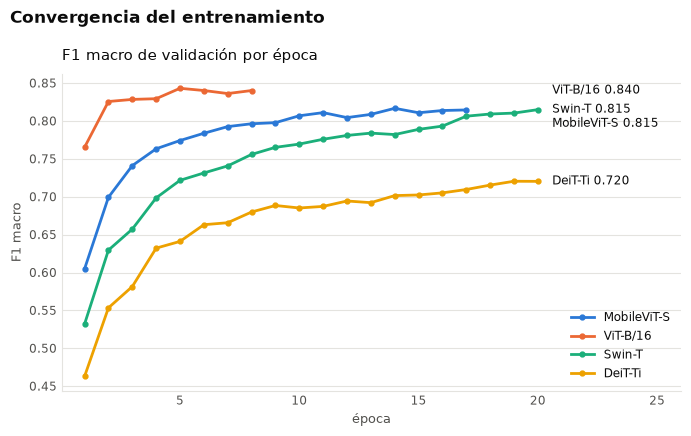

In [30]:
fig = cmp.plot_validation_curves(historias)
guardar(fig, "convergencia")
plt.show()

El F1 de validación y el de test de cada modelo. La validación sale de `train`, que tiene ruido de etiquetas a propósito; `test` fue curado a mano:

In [31]:
val_vs_test = pd.DataFrame(
    {
        "Mejor F1 de validación": {m: metrics[m]["best_val_f1_macro"] for m in MODELOS},
        "F1 de test": {m: metrics[m]["test"]["f1_macro"] for m in MODELOS},
    }
)
val_vs_test["Test − validación"] = val_vs_test["F1 de test"] - val_vs_test["Mejor F1 de validación"]
val_vs_test.to_csv(OUT_DIR / "validacion_vs_test.csv")
val_vs_test.rename(index=NOMBRE)

,Mejor F1 de validación,F1 de test,Test − validación
MobileViT-S,0.8167,0.8609,0.0442
ViT-B/16,0.8431,0.8838,0.0407
Swin-T,0.8149,0.8547,0.0397
DeiT-Ti,0.7204,0.7765,0.0561


**Lectura.** Varios aspectos acotan el alcance de los resultados:

- **Convergencia.** Dos de los cuatro modelos llegaron al tope de 20 épocas con el F1 de validación todavía subiendo: DeiT-Ti (1,1 puntos en las últimas 3 épocas) y Swin-T (0,9). Sus resultados son cotas inferiores, aunque en el caso de Swin-T la sección 2 mostró que esa cota es ajustada: 10 épocas más no mejoraron el test. Los otros dos los cortó el early stopping y sí convergieron: MobileViT-S (mejor época 14, corte en la 17) y ViT-B/16 (mejor en la 5, corte en la 8).
- **Pérdida frente a F1.** En MobileViT-S, Swin-T y DeiT-Ti la pérdida de validación toca su mínimo entre las épocas 8 y 9 y después sube, mientras el F1 sigue creciendo: los modelos se vuelven más confiados en sus errores aunque acierten más. En ViT-B/16 las dos curvas van de la mano: el mínimo de pérdida y el mejor F1 caen en la misma época.
- **Validación frente a test.** El F1 de test queda entre 4,0 y 5,6 puntos por encima del de validación en los cuatro modelos. No es una fuga: la validación sale de `train`, que tiene ruido de etiquetas a propósito, y `test` fue curado a mano. Afecta a todos de manera parecida, así que la elección por validación de la sección 2.1 es consistente con el test.
- **Barrido incompleto y una sola semilla.** DeiT-Ti no se probó con lr 5e-5 y Swin-T no se probó con otro learning rate. Por lo que pasó con MobileViT-S, es poco probable que a los modelos chicos les convenga bajarlo, pero para Swin-T (27,6 M) no se sabe. Cada corrida se entrenó una sola vez (semilla 42): los intervalos de las secciones 2, 4 y 6 cubren la variación por muestra de imágenes, no la variación entre corridas de entrenamiento.

## 10. Síntesis para el informe

Los números clave, calculados en las secciones anteriores, se exportan a `hallazgos.json` para que el informe los cite sin copiarlos a mano. Si se agrega o reentrena alguna corrida, alcanza con volver a correr este notebook: la elección de la mejor receta por arquitectura es automática.

In [32]:
(OUT_DIR / "hallazgos.json").write_text(
    json.dumps(hallazgos, indent=2, ensure_ascii=False), encoding="utf-8"
)
print("guardado:", (OUT_DIR / "hallazgos.json").relative_to(REPORTS_DIR.parent))
print(f"{len(hallazgos)} valores")

guardado: reports/results/comparativa/hallazgos.json
68 valores


### Hallazgos principales

1. **La receta pesa tanto como la arquitectura, y con signo distinto según el tamaño del modelo.** Bajar el learning rate de 5e-4 a 5e-5 le suma 6,0 puntos de accuracy a ViT-B/16 (de 82,4 % a 88,4 %) y le resta 3,9 a MobileViT-S. Darle 30 épocas en vez de 20 a Swin-T no cambia nada. Por eso cada arquitectura entra al benchmark con su propia receta, elegida por validación.
2. **La referencia es la mejor.** ViT-B/16 (85,9 M de parámetros) obtiene el mejor F1 macro (0,884) y supera a MobileViT-S por 2,3 puntos de accuracy (IC 95 % de 1,9 a 2,7), a Swin-T por 2,9 y a DeiT-Ti por 10,7.
3. **MobileViT-S es la opción eficiente: pierde poco y cuesta mucho menos.** Conserva el 97,4 % del F1 de la referencia con 17 veces menos parámetros, 9 veces menos GFLOPs, un octavo del tamaño cuantizado y un 39 % de su latencia en CPU int8. Es, junto con ViT-B/16, el único modelo en el frente de Pareto de los tres ejes de costo. Entre candidatos supera a Swin-T por 0,6 puntos siendo 5,5 veces más chico, y a DeiT-Ti por 8,4.
4. **El tamaño no alcanza: la arquitectura importa.** DeiT-Ti, con casi los mismos parámetros que MobileViT-S, queda 8 puntos por debajo; es, en cambio, el más rápido en CPU (19 ms contra 75 ms) y la alternativa si la latencia es la restricción dominante.
5. **La ventaja de la referencia es pareja entre clases.** MobileViT-S queda entre 1,9 y 2,6 puntos por debajo en los tres terciles de dificultad del EDA, con intervalos que se superponen y sin tendencia clara con la dificultad (ρ ≈ 0,16), y pierde en 82 de 101 clases por una media de 2,3 puntos de F1. La hipótesis de que la capacidad extra marcaría diferencia sobre todo en las clases confundibles no se confirma. DeiT-Ti sí pierde más en las clases difíciles (de 7,5 a 12,9 puntos).
6. **Hay un núcleo de errores que no depende del modelo.** Las confusiones dominantes (steak ↔ filet mignon, chocolate cake ↔ chocolate mousse, los dos tartares) son las mismas en las cuatro arquitecturas y la capacidad extra de la referencia no las elimina. El 4,5 % del test lo fallan los cuatro modelos, y en 280 imágenes coinciden en la misma clase equivocada.

### En una frase

**MobileViT-S pierde unos 2,3 puntos de accuracy frente a la referencia, a un costo 17 veces menor, y esa pérdida es uniforme entre clases fáciles y difíciles.**

### Limitaciones

- El barrido de recetas es incompleto: dos learning rates para ViT-B/16 y MobileViT-S, dos topes de épocas para Swin-T, una sola corrida para DeiT-Ti. Swin-T con un learning rate menor y DeiT-Ti con cualquier otra receta quedan sin probar.
- Una sola semilla por corrida; los intervalos no cubren la variación entre entrenamientos.
- Swin-T y DeiT-Ti no convergieron en 20 épocas (aunque para Swin-T 30 épocas no cambiaron el test).
- Las latencias se midieron en la CPU de una notebook (un hilo), no en un dispositivo móvil real. Sirven para comparar modelos entre sí, no para predecir la latencia absoluta en un teléfono.

## 11. Artefactos generados

In [33]:
for p in sorted(OUT_DIR.iterdir()):
    print(" -", p.relative_to(REPORTS_DIR.parent))
for p in sorted(FIGURES_DIR.glob("comparativa-*")):
    print(" -", p.relative_to(REPORTS_DIR.parent))

 - reports/results/comparativa/accuracy_por_tercil_subset.csv
 - reports/results/comparativa/brecha_por_clase.csv
 - reports/results/comparativa/brecha_por_tercil_subset.csv
 - reports/results/comparativa/brecha_por_tercil_test.csv
 - reports/results/comparativa/brecha_vs_dificultad.csv
 - reports/results/comparativa/confusiones_compartidas.csv
 - reports/results/comparativa/convergencia.csv
 - reports/results/comparativa/corridas.csv
 - reports/results/comparativa/diferencias_entre_candidatos.csv
 - reports/results/comparativa/diferencias_vs_referencia.csv
 - reports/results/comparativa/efecto_receta.csv
 - reports/results/comparativa/frente_de_pareto.csv
 - reports/results/comparativa/hallazgos.json
 - reports/results/comparativa/mejor_corrida_por_arquitectura.csv
 - reports/results/comparativa/tabla_comparativa.csv
 - reports/results/comparativa/validacion_vs_test.csv
 - reports/figures/comparativa-brecha-por-clase-mobilevit.png
 - reports/figures/comparativa-brecha-por-clase-swin.p